# Modelagem de IA da FarmTech Solutions
## FIAP IA 2026/1 | Fase 3 | Capítulo 10

**Atividade 2:** A Primeira Técnica de Aprendizado de Máquina  
**Grupo 45:** Vinicius Anjos (RM572814), Higor Henrique Garcia (RM571820), Igor (RM572822) e Humberto (RM570536)  
**Aluno responsável pela consolidação:** Higor Henrique Garcia — **RM571820**  
**Dataset:** `produtos_agricolas.csv`

Este notebook consolida a entrega do grupo em um relatório único, com análise exploratória,
análise descritiva, identificação de perfil ideal de solo/clima, comparação de três culturas
e desenvolvimento de cinco modelos preditivos para recomendar a cultura agrícola mais adequada.


## 1. Contexto e Objetivo

A FarmTech Solutions atua como uma consultoria fictícia de agronegócio orientada por dados.
A base usada neste trabalho contém medições de condições de solo e clima, associadas ao tipo
de cultura agrícola recomendado para cada cenário.

O objetivo é responder a quatro pontos do enunciado:

- fazer uma análise exploratória da base;
- narrar uma análise descritiva com pelo menos cinco gráficos;
- encontrar um perfil ideal de solo/clima e comparar três culturas;
- treinar cinco modelos preditivos com algoritmos distintos e comparar sua performance.

### Nota de autoria e originalidade

A consolidação foi feita a partir das branches e notebooks do grupo, mas o relatório final
não é uma cópia direta da referência. As decisões de organização, a escolha das três culturas,
a sequência dos gráficos, a leitura dos resultados e as conclusões foram reescritas para formar
uma narrativa única do Grupo 45. O notebook também inclui rastreabilidade das partes usadas,
execução reproduzível e comentários específicos sobre os resultados obtidos neste dataset.


## 2. Importações e Configuração


In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

GRAFICOS_DIR = Path("graficos")
GRAFICOS_DIR.mkdir(exist_ok=True)

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 3. Carregamento e Visão Geral dos Dados


In [2]:
csv_path = Path("produtos_agricolas.csv")
if not csv_path.exists():
    raise FileNotFoundError(
        "Arquivo produtos_agricolas.csv não encontrado. "
        "Execute o notebook a partir da raiz do repositório."
    )

df = pd.read_csv(csv_path)
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
labels_pt = {
    "N": "Nitrogênio (N)",
    "P": "Fósforo (P)",
    "K": "Potássio (K)",
    "temperature": "Temperatura (°C)",
    "humidity": "Umidade (%)",
    "ph": "pH do solo",
    "rainfall": "Chuva (mm)",
}

print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Culturas distintas: {df['label'].nunique()}")
display(df.head(10))


Shape: 2200 linhas x 8 colunas
Culturas distintas: 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,93,19,59,25.713620,92.424861,6.613252,24.183549,muskmelon
1,99,17,42,25.755171,90.687041,6.677987,51.310634,watermelon
2,34,56,49,31.932154,92.972340,6.902555,156.413743,papaya
3,53,67,56,33.077583,88.035813,5.816981,137.743190,papaya
4,14,143,191,20.630108,91.844701,6.073189,116.278481,apple
5,22,25,28,32.088290,55.094527,6.040989,110.600868,mango
6,23,152,213,20.655330,84.529718,6.843846,158.379832,apple
7,15,37,21,23.934809,59.775824,6.836738,83.430930,mothbeans
8,21,43,23,26.359617,92.876162,6.341467,51.193023,mungbean
9,18,63,17,25.658694,73.772161,6.648743,46.989338,lentil


In [3]:
resumo_estrutura = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "valores_unicos": df.nunique().values,
})

print("Resumo estrutural da base:")
display(resumo_estrutura)

print("Estatísticas descritivas das variáveis numéricas:")
display(df[features].describe().T.round(2))


Resumo estrutural da base:


,coluna,tipo,nulos,valores_unicos
0,N,int64,0,129
1,P,int64,0,140
2,K,int64,0,134
3,temperature,float64,0,2200
4,humidity,float64,0,2184
5,ph,float64,0,2198
6,rainfall,float64,0,2200
7,label,str,0,22


Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
N,2200.0,49.65,35.71,8.00,19.75,30.00,84.00,140.00
P,2200.0,52.92,33.26,3.00,24.00,49.00,67.00,156.00
K,2200.0,47.71,51.07,0.00,20.00,31.00,49.00,225.00
temperature,2200.0,25.55,4.13,14.60,22.68,25.37,28.32,38.05
humidity,2200.0,71.54,22.34,8.18,57.69,79.58,88.63,99.90
ph,2200.0,6.46,0.64,4.46,5.99,6.48,6.94,8.58
rainfall,2200.0,104.12,53.93,6.15,61.60,95.16,137.26,351.58


## 4. Análise Exploratória e Descritiva

Esta seção apresenta os gráficos usados para entender distribuição das culturas, comportamento
das variáveis numéricas, correlações e padrões visuais por cultura. Os gráficos também são
salvos na pasta `graficos/` para facilitar apresentação ou reaproveitamento.


### Gráfico 1 — Distribuição das Culturas


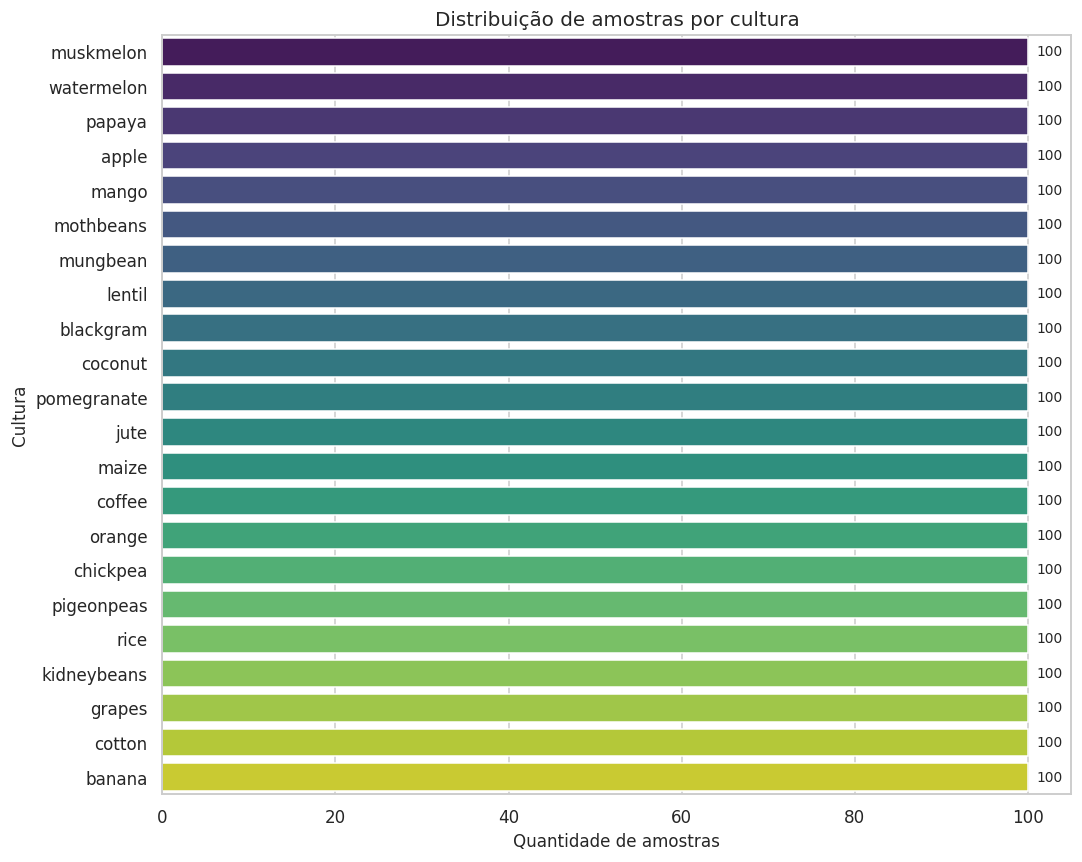

Todas as culturas têm a mesma quantidade de amostras? True


In [4]:
contagem_culturas = df["label"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=contagem_culturas.values, y=contagem_culturas.index, ax=ax, palette="viridis")
ax.set_title("Distribuição de amostras por cultura")
ax.set_xlabel("Quantidade de amostras")
ax.set_ylabel("Cultura")

for i, valor in enumerate(contagem_culturas.values):
    ax.text(valor + 1, i, str(valor), va="center", fontsize=9)

fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico1_distribuicao_culturas.png", bbox_inches="tight")
plt.show()

print("Todas as culturas têm a mesma quantidade de amostras?",
      contagem_culturas.nunique() == 1)


A base é balanceada: cada cultura aparece com a mesma quantidade de registros.
Isso reduz o risco de um modelo ter alta acurácia apenas por favorecer classes majoritárias.


### Gráfico 2 — Distribuição das Variáveis Numéricas


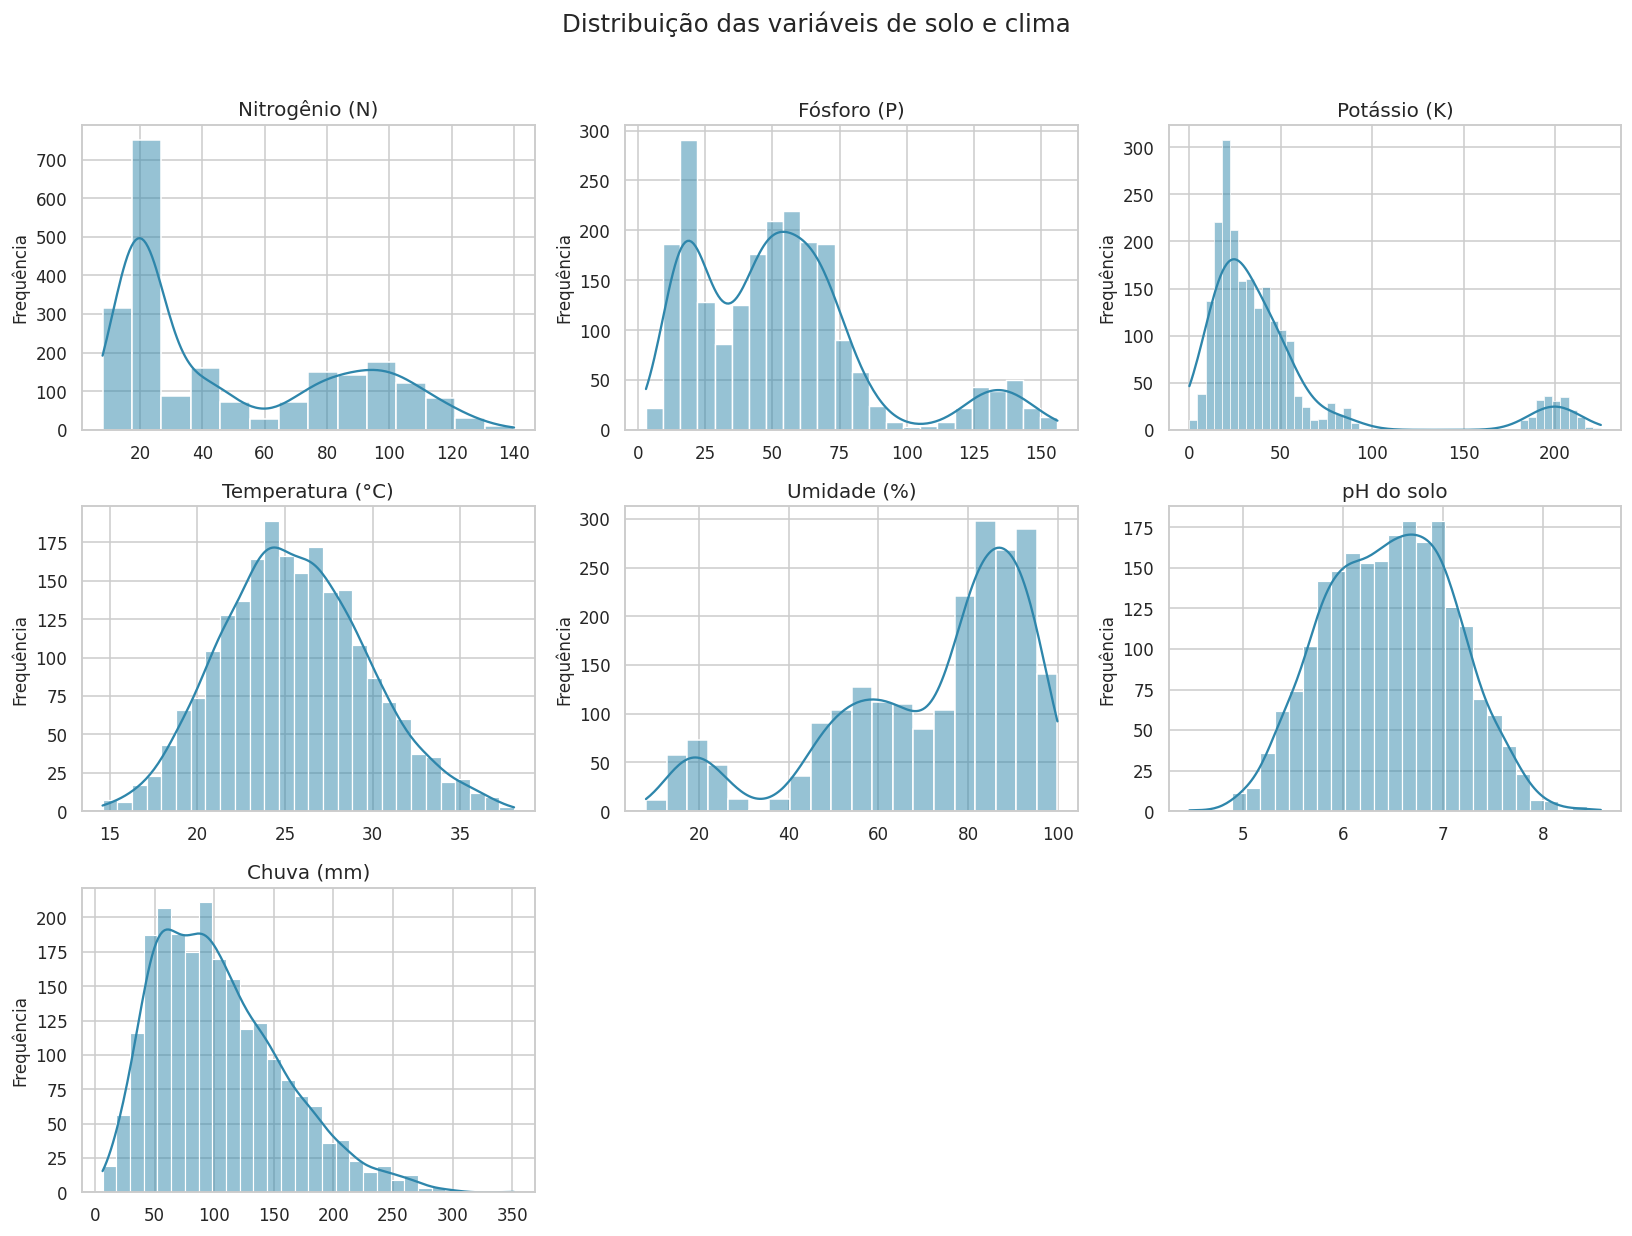

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2E86AB")
    axes[i].set_title(labels_pt[col])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequência")

for j in range(len(features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribuição das variáveis de solo e clima", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico2_distribuicao_variaveis.png", bbox_inches="tight")
plt.show()


As variáveis apresentam escalas e formatos de distribuição diferentes. Nutrientes como `N`,
`P` e `K` possuem faixas bem segmentadas entre culturas, enquanto temperatura, umidade, pH
e chuva ajudam a separar perfis climáticos.


### Gráfico 3 — Correlação entre Variáveis


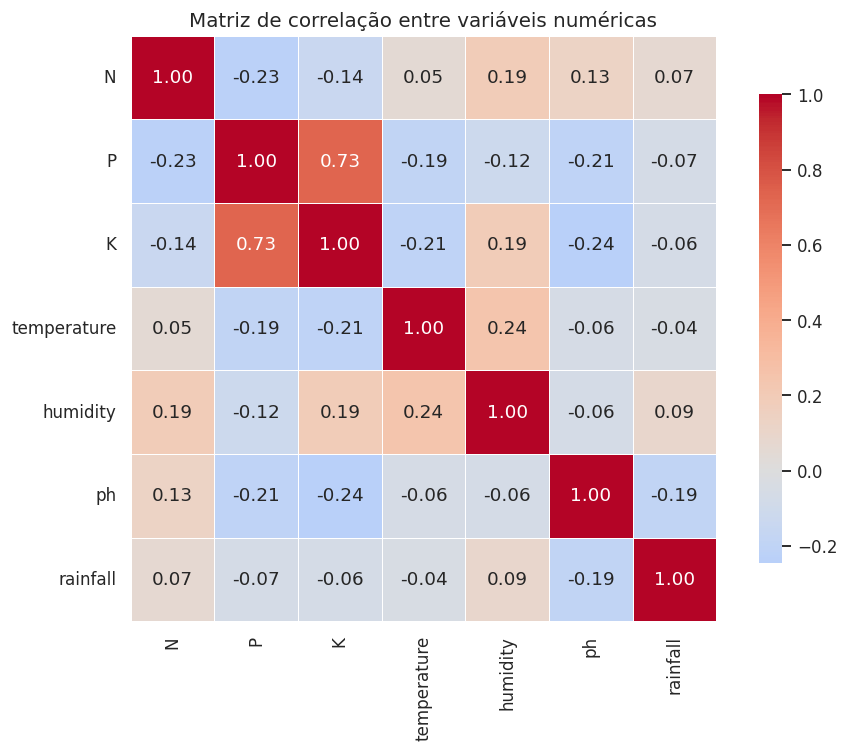

Maiores correlações absolutas:


correlação
P           K                 0.731
K           ph               -0.245
temperature humidity          0.243
N           P                -0.229
P           ph               -0.209
K           temperature      -0.207
            humidity          0.189

In [6]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Matriz de correlação entre variáveis numéricas")
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico3_correlacao.png", bbox_inches="tight")
plt.show()

pares = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Maiores correlações absolutas:")
display(pares.head(7).rename("correlação").round(3).to_frame())


A correlação mais forte aparece entre `P` e `K`, indicando que algumas culturas exigem
níveis altos desses nutrientes simultaneamente. A chuva também se relaciona com umidade,
o que é coerente do ponto de vista climático.


### Gráfico 4 — Níveis de NPK por Cultura


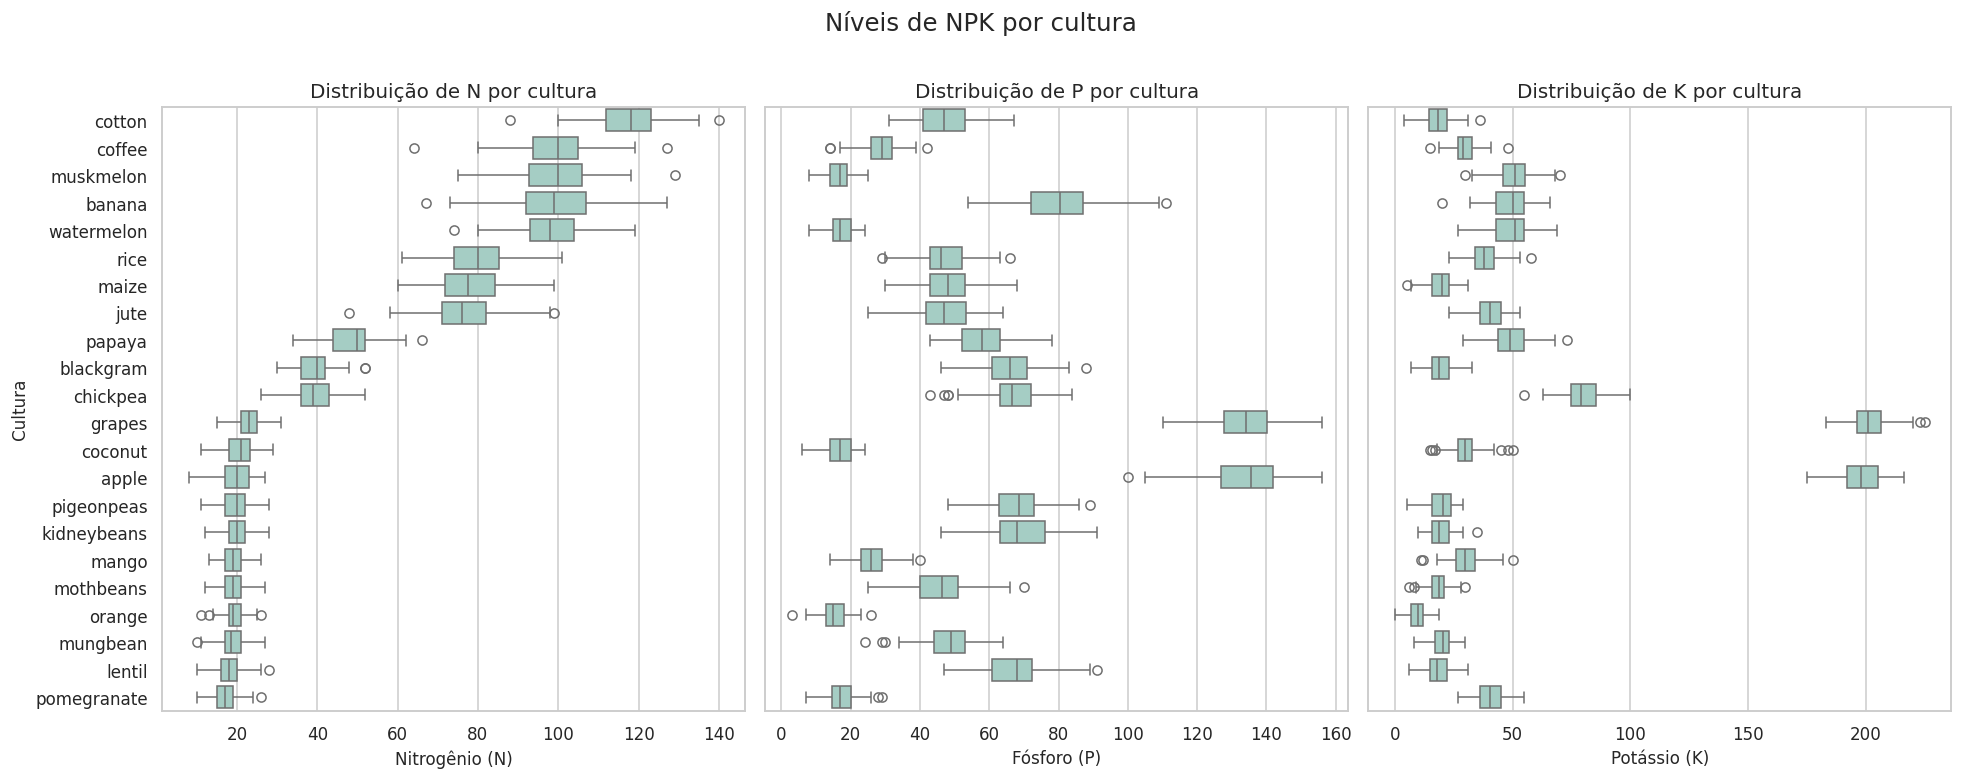

Top 5 culturas por média de Nitrogênio:


,N,P,K
label,,,
cotton,117.70,47.37,18.42
muskmelon,99.93,16.63,50.61
banana,99.59,80.13,49.12
coffee,99.55,28.62,29.59
watermelon,98.33,17.20,49.51


In [7]:
media_npk = df.groupby("label")[["N", "P", "K"]].mean().sort_values("N", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
for ax, nutriente in zip(axes, ["N", "P", "K"]):
    ordem = df.groupby("label")[nutriente].median().sort_values(ascending=False).index
    sns.boxplot(data=df, y="label", x=nutriente, order=ordem, ax=ax, color="#9FD3C7")
    ax.set_title(f"Distribuição de {nutriente} por cultura")
    ax.set_xlabel(labels_pt[nutriente])
    ax.set_ylabel("Cultura" if nutriente == "N" else "")

fig.suptitle("Níveis de NPK por cultura", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico4_npk_por_cultura.png", bbox_inches="tight")
plt.show()

print("Top 5 culturas por média de Nitrogênio:")
display(media_npk.head(5).round(2))


O gráfico mostra que as culturas têm exigências nutricionais bastante diferentes. Culturas
como cotton, banana e coffee aparecem com maior necessidade média de nitrogênio, enquanto
outras dependem mais de fósforo e potássio.


### Gráfico 5 — Temperatura vs. Umidade por Cultura


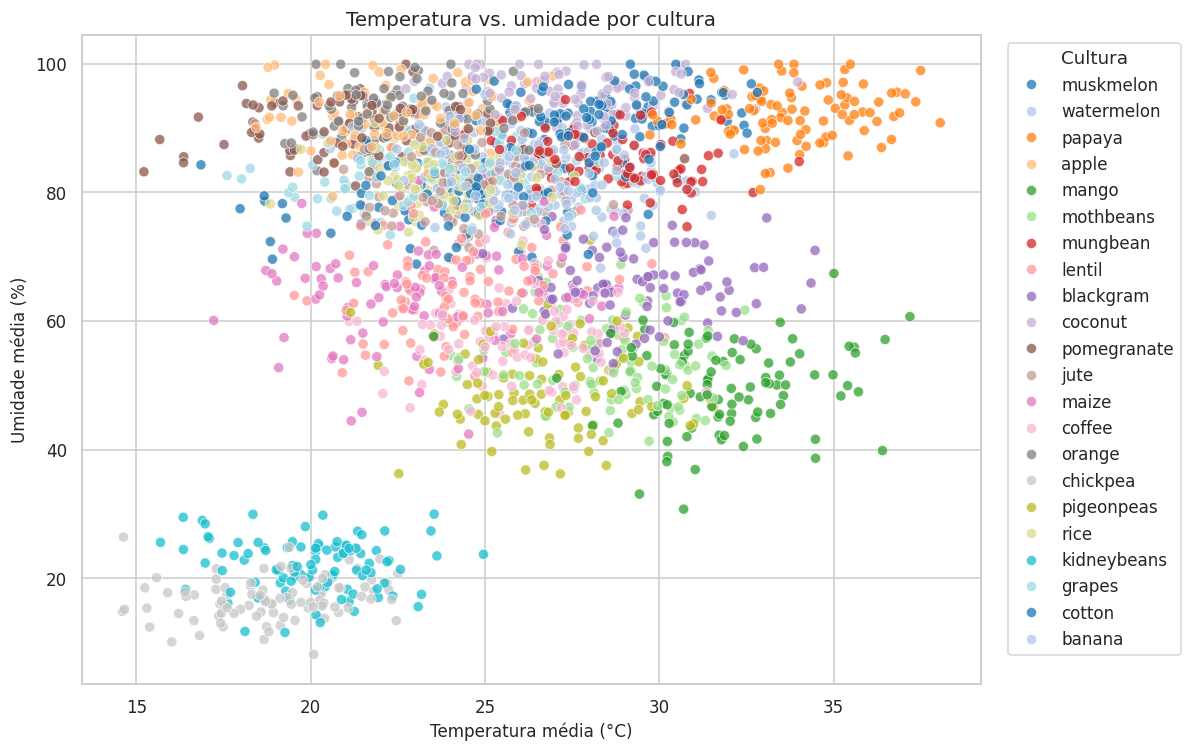

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x="temperature",
    y="humidity",
    hue="label",
    palette="tab20",
    alpha=0.75,
    s=45,
    ax=ax,
)
ax.set_title("Temperatura vs. umidade por cultura")
ax.set_xlabel("Temperatura média (°C)")
ax.set_ylabel("Umidade média (%)")
ax.legend(title="Cultura", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico5_temperatura_umidade.png", bbox_inches="tight")
plt.show()


A relação entre temperatura e umidade ajuda a separar culturas com perfis climáticos
extremos. Algumas culturas se concentram em alta umidade, enquanto outras aparecem em
regiões mais secas ou com temperatura média mais elevada.


### Gráfico 6 — Chuva por Cultura


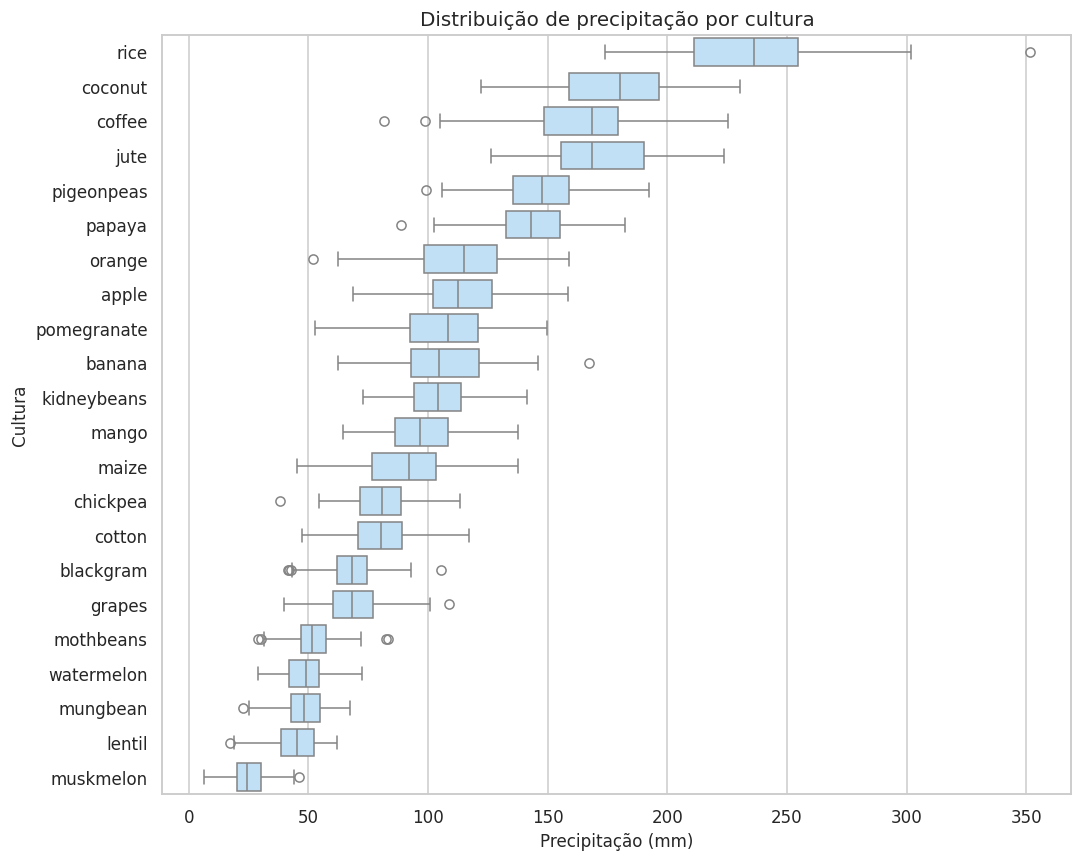

In [9]:
ordem_chuva = df.groupby("label")["rainfall"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, y="label", x="rainfall", order=ordem_chuva, ax=ax, color="#B8E1FF")
ax.set_title("Distribuição de precipitação por cultura")
ax.set_xlabel("Precipitação (mm)")
ax.set_ylabel("Cultura")
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico6_chuva_por_cultura.png", bbox_inches="tight")
plt.show()


A precipitação é uma das variáveis mais úteis para diferenciar culturas. Rice, por exemplo,
depende de níveis de chuva muito maiores do que culturas como muskmelon ou watermelon.


## 5. Perfil Ideal de Solo e Clima


Para representar um perfil de referência da base, usamos a mediana de cada variável numérica.
A mediana é menos sensível a valores extremos do que a média e resume bem o centro do conjunto.

As três culturas escolhidas para comparação são **rice**, **coffee** e **banana**, pois possuem
perfis agrícolas diferentes: arroz é fortemente associado à água/chuva, café tem perfil tropical
e nutricional próprio, e banana combina alta demanda de nutrientes com alta umidade.


In [10]:
perfil_ideal = df[features].median().rename("perfil_ideal")
culturas_escolhidas = ["rice", "coffee", "banana"]
perfis_culturas = df.groupby("label")[features].median().loc[culturas_escolhidas]
perfis_comparacao = pd.concat([perfil_ideal.to_frame().T, perfis_culturas])

display(perfis_comparacao.rename(columns=labels_pt).round(2))


,Nitrogênio (N),Fósforo (P),Potássio (K),Temperatura (°C),Umidade (%),pH do solo,Chuva (mm)
perfil_ideal,30.0,49.0,31.0,25.37,79.58,6.48,95.16
rice,80.0,46.0,38.0,23.69,82.08,6.53,236.09
coffee,100.0,29.0,29.0,26.06,57.82,6.82,168.52
banana,99.0,80.5,50.0,27.26,80.29,5.98,104.76


### Gráfico 7 — Perfil Ideal vs. Três Culturas


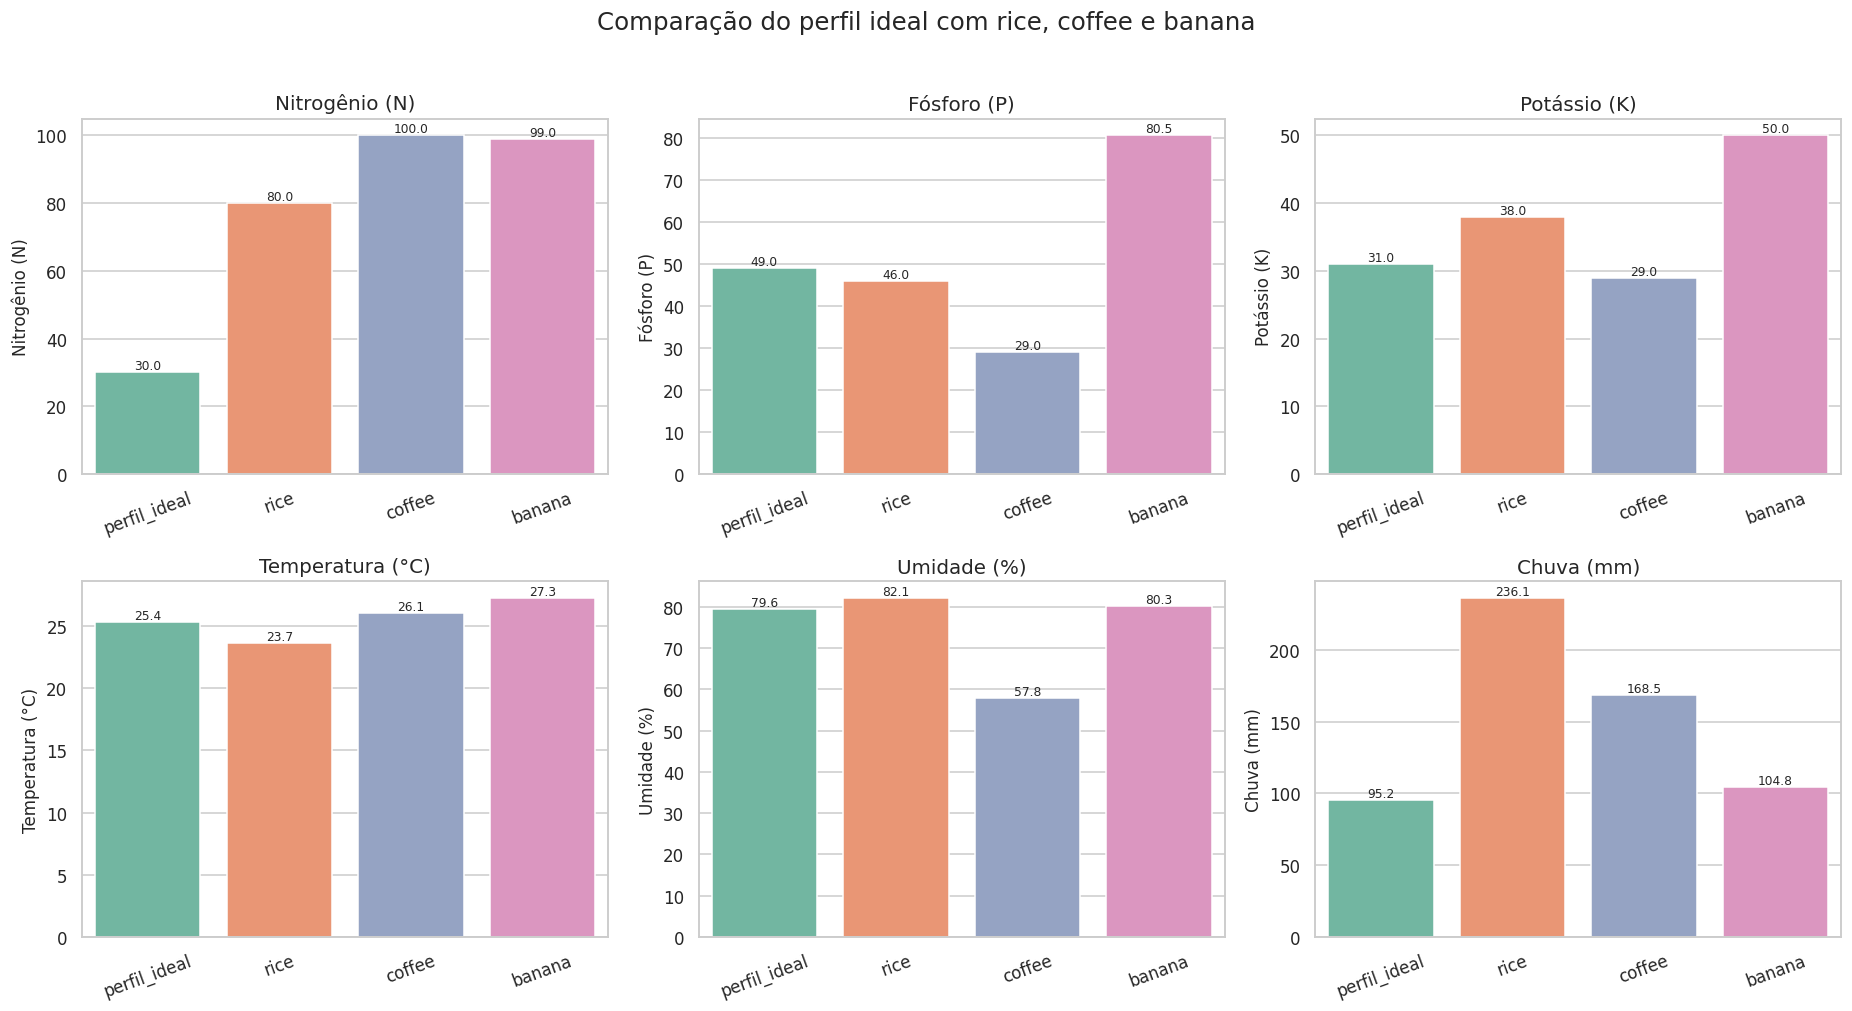

In [11]:
variaveis_perfil = ["N", "P", "K", "temperature", "humidity", "rainfall"]
dados_perfil = perfis_comparacao[variaveis_perfil].rename(columns=labels_pt)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for ax, col in zip(axes, dados_perfil.columns):
    sns.barplot(x=dados_perfil.index, y=dados_perfil[col], ax=ax, palette="Set2")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=8)

fig.suptitle("Comparação do perfil ideal com rice, coffee e banana", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico7_perfil_ideal_3_culturas.png", bbox_inches="tight")
plt.show()


**Rice** fica acima do perfil ideal em umidade e principalmente chuva, mostrando necessidade
de ambiente mais úmido. **Coffee** tem maior exigência de nitrogênio e chuva acima da mediana,
mas não tão extrema quanto rice. **Banana** apresenta alta exigência de NPK e umidade elevada,
indicando maior dependência de fertilidade do solo e clima úmido.


## 6. Preparação dos Dados para Machine Learning


In [12]:
X = df[features].copy()
y_texto = df["label"].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_texto)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")
print(f"Classes: {len(label_encoder.classes_)} culturas")


Treino: 1760 registros
Teste: 440 registros
Classes: 22 culturas


A divisão usa 80% dos dados para treino e 20% para teste, com `stratify=y` para manter a
proporção das culturas nos dois conjuntos. Variáveis padronizadas são usadas nos modelos
sensíveis à escala, como KNN e Naive Bayes.


## 7. Modelos Preditivos


In [13]:
modelos = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        X_train,
        X_test,
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=120, random_state=42),
        X_train,
        X_test,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        X_train,
        X_test,
    ),
    "K-Nearest Neighbors (k=5)": (
        KNeighborsClassifier(n_neighbors=5),
        X_train_scaled,
        X_test_scaled,
    ),
    "Naive Bayes (Gaussian)": (
        GaussianNB(),
        X_train_scaled,
        X_test_scaled,
    ),
}

resultados = {}

print("Treinando modelos...\n")
for nome, (modelo, X_tr, X_te) in modelos.items():
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    resultados[nome] = {
        "modelo": modelo,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "X_test_usado": X_te,
    }
    print(
        f"{nome:28s} accuracy={resultados[nome]['accuracy']:.4f} "
        f"f1_macro={resultados[nome]['f1_macro']:.4f}"
    )


Treinando modelos...

Decision Tree                accuracy=0.9227 f1_macro=0.9218


Random Forest                accuracy=0.9750 f1_macro=0.9750


Gradient Boosting            accuracy=0.9500 f1_macro=0.9502
K-Nearest Neighbors (k=5)    accuracy=0.9659 f1_macro=0.9659
Naive Bayes (Gaussian)       accuracy=0.9795 f1_macro=0.9795


### Gráfico 8 — Comparação de Performance dos Modelos


,Accuracy,F1 Macro
Naive Bayes (Gaussian),0.979545,0.979534
Random Forest,0.975,0.974977
K-Nearest Neighbors (k=5),0.965909,0.965868
Gradient Boosting,0.95,0.950167
Decision Tree,0.922727,0.921823


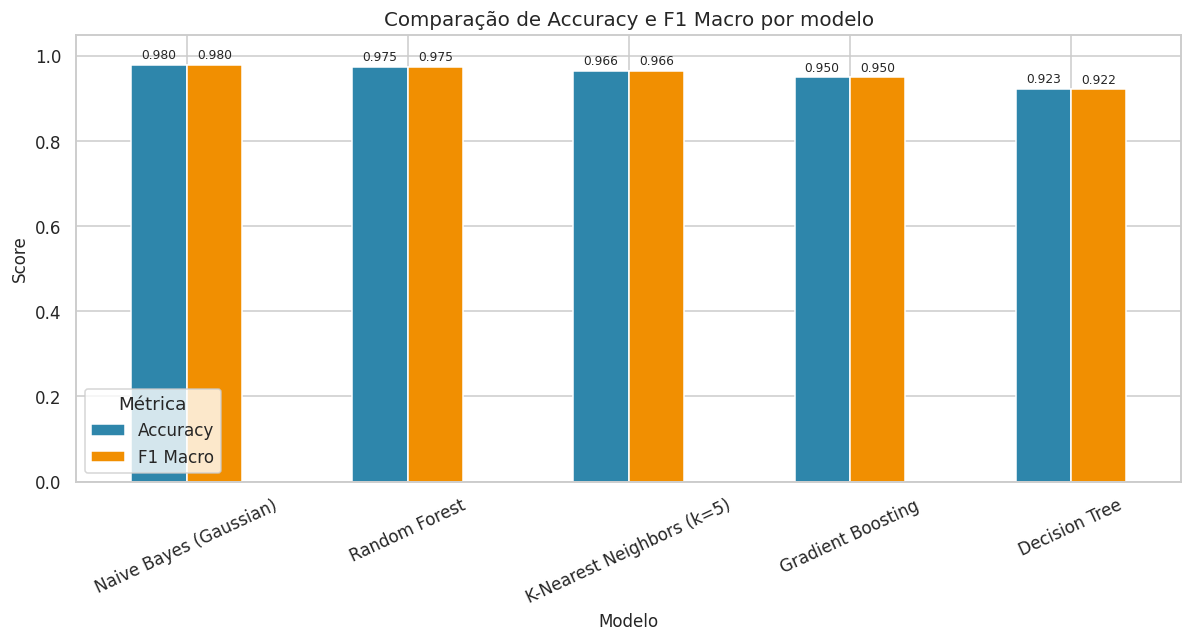

Melhor modelo por F1 Macro: Naive Bayes (Gaussian)


In [14]:
df_resultados = (
    pd.DataFrame(resultados)
    .T[["accuracy", "f1_macro"]]
    .rename(columns={"accuracy": "Accuracy", "f1_macro": "F1 Macro"})
    .sort_values("F1 Macro", ascending=False)
)

display(df_resultados.round(4))

fig, ax = plt.subplots(figsize=(11, 6))
df_resultados.plot(kind="bar", ax=ax, color=["#2E86AB", "#F18F01"], edgecolor="white")
ax.set_title("Comparação de Accuracy e F1 Macro por modelo")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Métrica")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico8_comparacao_modelos.png", bbox_inches="tight")
plt.show()

melhor_modelo_nome = df_resultados.index[0]
print(f"Melhor modelo por F1 Macro: {melhor_modelo_nome}")


Como o problema é multiclasse e a base é balanceada, `accuracy` é informativa.
Ainda assim, o `F1 Macro` é importante porque calcula desempenho médio por classe,
tratando todas as culturas com o mesmo peso.


### Gráfico 9 — Matriz de Confusão do Melhor Modelo


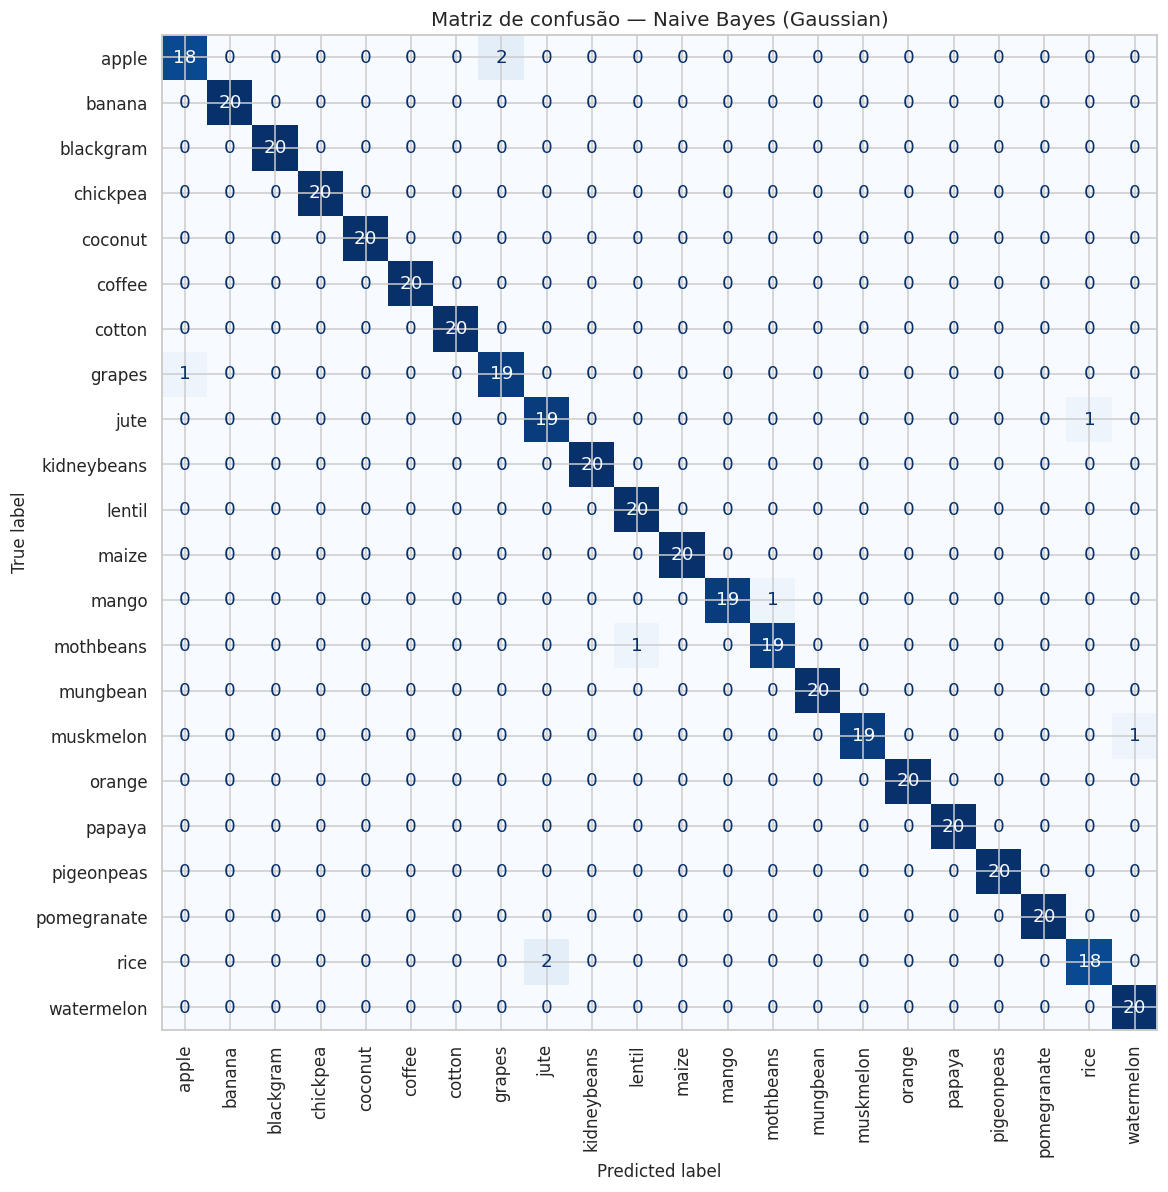

              precision    recall  f1-score   support

       apple      0.947     0.900     0.923        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     1.000     1.000        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      0.905     0.950     0.927        20
        jute      0.905     0.950     0.927        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      0.952     1.000     0.976        20
       maize      1.000     1.000     1.000        20
       mango      1.000     0.950     0.974        20
   mothbeans      0.950     0.950     0.950        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     0.950     0.974        20
      orange      1.000     1.000     1.000        20
      papaya      1.000    

In [15]:
melhor = resultados[melhor_modelo_nome]
cm = confusion_matrix(y_test, melhor["y_pred"])

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False, values_format="d")
ax.set_title(f"Matriz de confusão — {melhor_modelo_nome}")
fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico9_matriz_confusao_melhor_modelo.png", bbox_inches="tight")
plt.show()

print(classification_report(
    y_test,
    melhor["y_pred"],
    target_names=label_encoder.classes_,
    digits=3,
))


### Gráfico 10 — Importância das Variáveis no Random Forest


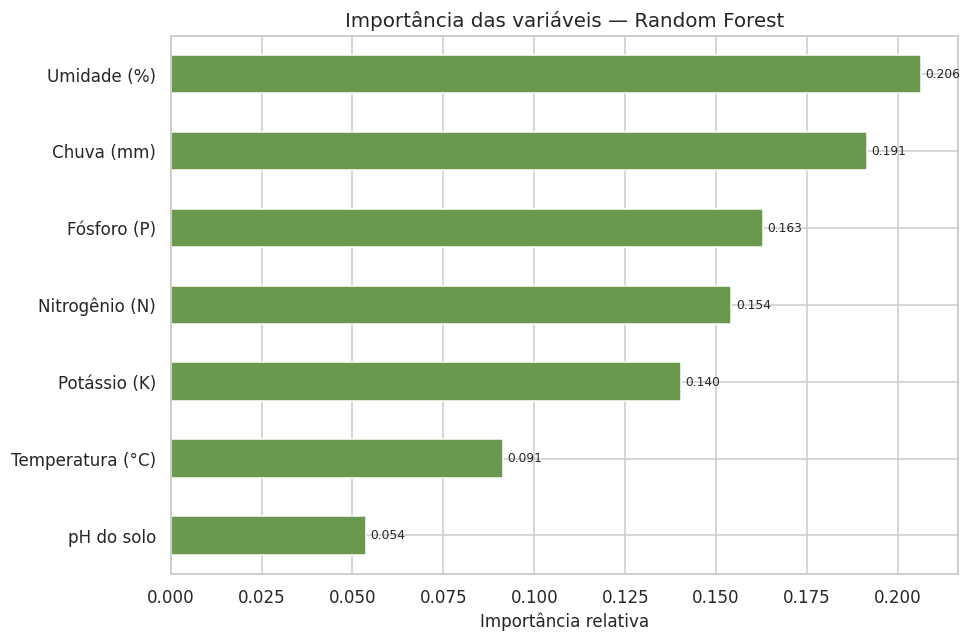

,importância
Umidade (%),0.2063
Chuva (mm),0.1913
Fósforo (P),0.1628
Nitrogênio (N),0.1542
Potássio (K),0.1403
Temperatura (°C),0.0914
pH do solo,0.0536


In [16]:
rf_model = resultados["Random Forest"]["modelo"]
importancias = (
    pd.Series(rf_model.feature_importances_, index=features)
    .sort_values(ascending=True)
    .rename(index=labels_pt)
)

fig, ax = plt.subplots(figsize=(9, 6))
importancias.plot(kind="barh", ax=ax, color="#6A994E")
ax.set_title("Importância das variáveis — Random Forest")
ax.set_xlabel("Importância relativa")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=3)

fig.tight_layout()
fig.savefig(GRAFICOS_DIR / "grafico10_importancia_variaveis.png", bbox_inches="tight")
plt.show()

display(importancias.sort_values(ascending=False).to_frame("importância").round(4))


As variáveis de umidade, chuva e nutrientes tendem a ser decisivas para separar as culturas.
Esse resultado é coerente com o domínio agrícola: disponibilidade hídrica e composição do solo
influenciam diretamente a recomendação de plantio.


## 8. Recomendações com o Melhor Modelo


In [17]:
exemplos = X_test.copy().head(8)
predicoes = label_encoder.inverse_transform(melhor["modelo"].predict(melhor["X_test_usado"][:8]))
reais = label_encoder.inverse_transform(y_test[:8])

tabela_exemplos = exemplos.copy()
tabela_exemplos["cultura_real"] = reais
tabela_exemplos["cultura_prevista"] = predicoes
display(tabela_exemplos.round(2))


,N,P,K,temperature,humidity,ph,rainfall,cultura_real,cultura_prevista
288,20,15,14,20.18,83.37,6.91,119.37,orange,orange
1708,120,87,48,28.09,85.37,5.59,91.96,banana,banana
390,110,51,13,25.46,89.01,7.13,89.57,cotton,cotton
17,80,57,13,26.78,68.55,6.02,83.88,maize,maize
1072,20,18,6,21.88,93.90,7.14,120.15,orange,orange
305,34,76,78,20.24,13.78,6.68,93.27,chickpea,chickpea
664,62,42,33,24.17,78.67,5.84,279.97,rice,rice
35,38,54,29,30.64,63.05,7.43,56.33,blackgram,blackgram


Em uma aplicação prática, a FarmTech poderia receber leituras de sensores de solo e clima,
passar essas condições pelo modelo e retornar a cultura mais indicada para aquele talhão.
Para um pequeno produtor, essa recomendação seria mais útil como uma triagem inicial: indicar
quais culturas parecem compatíveis com o solo e o clima antes de investir em análise agronômica
mais cara. O resultado deve ser usado como apoio à decisão, não como substituto de validação
técnica em campo.


## 9. Conclusões


A análise mostra que o dataset é bem organizado, balanceado e contém variáveis com forte
capacidade de diferenciação entre culturas. Isso ficou claro já nos primeiros gráficos:
mesmo antes dos modelos, era possível perceber "grupos" de culturas com exigências parecidas
de nutrientes, umidade e chuva.

O perfil ideal baseado na mediana funciona como referência geral, mas cada cultura se afasta
dele de forma própria. Rice exige muito mais água, coffee combina alta demanda de nitrogênio
com precipitação relevante, e banana se destaca pela exigência de nutrientes e umidade.

Os cinco modelos avaliados apresentaram bom desempenho, com destaque para os modelos de maior
F1 Macro. A comparação por métricas, matriz de confusão e importância de variáveis atende às
boas práticas de um projeto de classificação multiclasse.

**Limitações:** a base representa um recorte tabular e não inclui fatores como safra, região,
custo, produtividade esperada, sazonalidade, pragas, manejo e ruído de sensores reais. Em um
projeto real da FarmTech, o próximo passo seria coletar dados por talhão ao longo do tempo,
registrar a cultura realmente plantada e comparar a recomendação do modelo com a produtividade
obtida. Só assim o protótipo sairia de uma recomendação estatística geral para uma ferramenta
ajustada à realidade da fazenda.


## 10. Rastreabilidade da Consolidação


- Vinicius Anjos — RM572814: Parte 1, análise exploratória e inspeção inicial.
- Higor Henrique Garcia — RM571820: Parte 2 e consolidação final do notebook.
- Igor — RM572822: Parte 3, perfil ideal e comparação de culturas.
- Humberto — RM570536: Parte 4, modelos preditivos e análise de desempenho.
- Parte 1: análise exploratória completada no notebook final com gráficos de distribuição.
- Parte 2: análise descritiva de Higor integrada com correlação, NPK e temperatura vs. umidade.
- Parte 3: branch `origin/parte3-igor` usada como insumo para o perfil ideal e comparação de culturas.
- Parte 4: branch `origin/humberto` usada como insumo para os cinco modelos, métricas e conclusões.
- Referência: `referencia_notebook_completo.ipynb` usada como base de organização e validação.
